# NB02 · ARI — Índice de Respuesta Autonómica
**PAC_v2 — Análisis v2**

Este notebook define y valida el **ARI (Autonomic Response Index)**, 
un índice que cuantifica la eficiencia de la respuesta cardiovascular 
y de arousal frente al estímulo hipóxico del evento EDO.

**Pregunta central:** dado un evento con caída de SpO₂ conocida, 
¿cuánta respuesta autonómica genera (FC, movimiento)? 
¿Esta respuesta es ortogonal a la severidad hipóxica o la refleja?

**Preguntas específicas:**
1. ¿El ARI varía sistemáticamente entre morfotipos curva (C1–C5)?
2. ¿Es ortogonal a drop_pct (dimensión independiente)?
3. ¿Es un rasgo del paciente (ICC alto) o de la noche?
4. ¿Qué cuadrantes clínicos emergen del espacio 2D ARI × drop_pct?

> **Contexto:** HR y MOV no mejoran la discriminación de morfotipo 
> sobre drop_pct (AUC −0.15pp). Su valor está en capturar la 
> *respuesta*, no el *estímulo*. El ARI formaliza esa dimensión.

In [1]:
# Celda 01 - Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

GOLD_DIR = Path('../gold')
FIGDIR   = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

In [2]:
# Celda 02 - Carga de datos
events = pd.read_parquet(GOLD_DIR / 'events.parquet')

# Filtro calidad + con morphotype_curve
valid = events[events['in_quality'] & events['morphotype_curve'].notna()].copy()
valid = valid.reset_index(drop=True)

# Severidad ordinal para correlaciones
sev_map = {'C1': 1, 'C2': 2, 'C3': 3, 'C4': 4, 'C5': 5}
valid['sev']    = valid['morphotype_curve'].map(sev_map)
valid['severe'] = valid['morphotype_curve'].isin(['C4', 'C5'])

print(f'Eventos calidad con morphotype_curve: {len(valid):,}')
print(f'Distribución:')
print(valid['morphotype_curve'].value_counts().sort_index())

Eventos calidad con morphotype_curve: 85,277
Distribución:
morphotype_curve
C1    55175
C2    21318
C3     3662
C4     4301
C5      821
Name: count, dtype: int64


## 2. ARI — Definición y cómputo

**Reencuadre conceptual:** SpO₂ es el *estímulo* hipóxico; 
HR y MOV son la *respuesta* autonómica. 

El ARI mide la 
**ganancia de respuesta por unidad de estímulo**:
- Un ARI alto significa: mucha respuesta autonómica para poca caída de SpO₂.
- Un ARI bajo significa: poca o nula respuesta frente a la hipoxia.

In [3]:
# Ganancias por componente
valid['hr_gain']  = valid['delta_hr_bpm'] / valid['drop_pct'].replace(0, np.nan)
valid['mov_gain'] = (valid['peak_mov'] - valid['baseline_mov']) / valid['drop_pct'].replace(0, np.nan)

# ARI = 0.6 × rank(hr_gain) + 0.4 × rank(mov_gain)
# Pesos: 0.6 FC (PPG más confiable) / 0.4 MOV (sensor de dedo, más ruidoso)
n = len(valid)
valid['ari'] = (
    0.6 * (valid['hr_gain'].rank(na_option='keep')  / n) +
    0.4 * (valid['mov_gain'].rank(na_option='keep') / n)
)

print('HR gain mediana por cluster (bpm/pp):')
print(valid.groupby('morphotype_curve')['hr_gain'].median().round(3))
print()
print('ARI [0-1] por cluster:')
print(valid.groupby('morphotype_curve')['ari'].describe()[['mean','std','50%']].round(3))

HR gain mediana por cluster (bpm/pp):
morphotype_curve
C1   0.633
C2   0.528
C3   0.209
C4   0.307
C5   0.040
Name: hr_gain, dtype: float64

ARI [0-1] por cluster:
                  mean   std   50%
morphotype_curve                  
C1               0.491 0.205 0.502
C2               0.526 0.185 0.522
C3               0.509 0.146 0.490
C4               0.489 0.143 0.480
C5               0.422 0.105 0.431


## 3. Figura definitoria del ARI

La figura siguiente muestra la anatomía completa del índice:
distribuciones de gains por cluster, síntesis del ARI, y la relación
estímulo-respuesta que justifica su diseño.

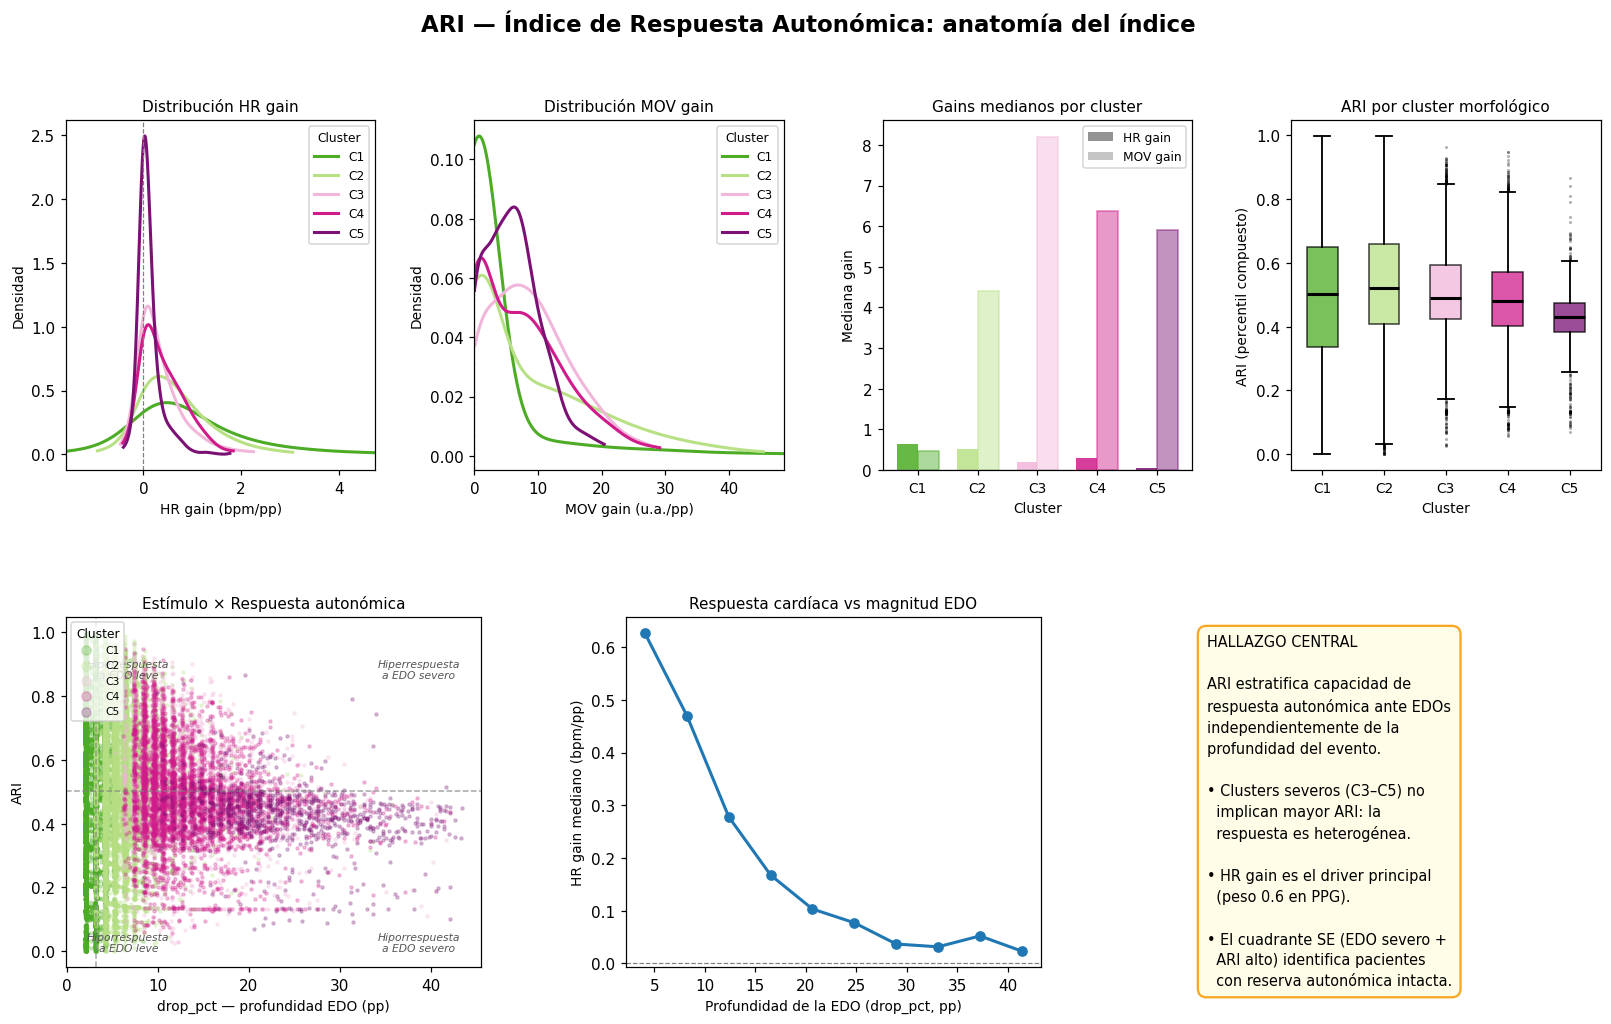

Guardada: 02_ari_definicion.png


In [4]:
cluster_order = ['C1','C2','C3','C4','C5']
palette = {'C1':'#4dac26','C2':'#b8e186','C3':'#f1b6da','C4':'#d01c8b','C5':'#7b1174'}
colors   = [palette[c] for c in cluster_order]

fig = plt.figure(figsize=(18, 10))
fig.suptitle('ARI — Índice de Respuesta Autonómica: anatomía del índice', fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                       width_ratios=[1, 1, 1])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0, :],
                                          wspace=0.32)
ax_hr  = fig.add_subplot(gs_top[0])
ax_mov = fig.add_subplot(gs_top[1])
ax_bar = fig.add_subplot(gs_top[2])
ax_ari = fig.add_subplot(gs_top[3])

ax_sc  = fig.add_subplot(gs[1, 0])
ax_ln  = fig.add_subplot(gs[1, 1])
ax_txt = fig.add_subplot(gs[1, 2])

from scipy.stats import gaussian_kde

# ── Fila superior ─────────────────────────────────────────────────────────────

# Panel 1: KDE de HR gain por cluster
for c, col in zip(cluster_order, colors):
    vals = valid.loc[valid['morphotype_curve']==c, 'hr_gain'].dropna()
    if len(vals) > 50:
        xr = np.linspace(vals.quantile(0.01), vals.quantile(0.99), 300)
        kde = gaussian_kde(vals, bw_method=0.3)
        ax_hr.plot(xr, kde(xr), color=col, lw=2, label=c)
ax_hr.axvline(0, color='grey', lw=0.8, ls='--')
ax_hr.set_xlabel('HR gain (bpm/pp)', fontsize=9)
ax_hr.set_ylabel('Densidad', fontsize=9)
ax_hr.set_title('Distribución HR gain', fontsize=10)
ax_hr.legend(fontsize=8, title='Cluster', title_fontsize=8)
ax_hr.set_xlim(valid['hr_gain'].quantile(0.01), valid['hr_gain'].quantile(0.99))

# Panel 2: KDE de MOV gain por cluster
for c, col in zip(cluster_order, colors):
    vals = valid.loc[valid['morphotype_curve']==c, 'mov_gain'].dropna()
    if len(vals) > 50:
        xr = np.linspace(vals.quantile(0.01), vals.quantile(0.99), 300)
        kde = gaussian_kde(vals, bw_method=0.3)
        ax_mov.plot(xr, kde(xr), color=col, lw=2, label=c)
ax_mov.axvline(0, color='grey', lw=0.8, ls='--')
ax_mov.set_xlabel('MOV gain (u.a./pp)', fontsize=9)
ax_mov.set_ylabel('Densidad', fontsize=9)
ax_mov.set_title('Distribución MOV gain', fontsize=10)
ax_mov.legend(fontsize=8, title='Cluster', title_fontsize=8)
ax_mov.set_xlim(valid['mov_gain'].quantile(0.01), valid['mov_gain'].quantile(0.99))

# Panel 3: Mediana de gains por cluster (barras agrupadas)
med_hr  = [valid.loc[valid['morphotype_curve']==c, 'hr_gain'].median() for c in cluster_order]
med_mov = [valid.loc[valid['morphotype_curve']==c, 'mov_gain'].median() for c in cluster_order]
x = np.arange(len(cluster_order))
w = 0.35
ax_bar.bar(x - w/2, med_hr,  width=w, color=colors, label='HR gain', alpha=0.85)
ax_bar.bar(x + w/2, med_mov, width=w, color=colors, label='MOV gain', alpha=0.45, edgecolor=colors, linewidth=1.2)
ax_bar.axhline(0, color='grey', lw=0.8)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(cluster_order, fontsize=9)
ax_bar.set_xlabel('Cluster', fontsize=9)
ax_bar.set_ylabel('Mediana gain', fontsize=9)
ax_bar.set_title('Gains medianos por cluster', fontsize=10)
from matplotlib.patches import Patch
ax_bar.legend(handles=[Patch(facecolor='grey', alpha=0.85, label='HR gain'),
                        Patch(facecolor='grey', alpha=0.45, label='MOV gain')],
              fontsize=8)

# Panel 4: ARI boxplot por cluster
data_ari = [valid.loc[valid['morphotype_curve']==c, 'ari'].dropna().values for c in cluster_order]
bp = ax_ari.boxplot(data_ari, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='.', ms=2, alpha=0.3))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax_ari.set_xticklabels(cluster_order, fontsize=9)
ax_ari.set_xlabel('Cluster', fontsize=9)
ax_ari.set_ylabel('ARI (percentil compuesto)', fontsize=9)
ax_ari.set_title('ARI por cluster morfológico', fontsize=10)

# ── Fila inferior ─────────────────────────────────────────────────────────────

# Panel 5: Scatter estímulo × respuesta
for c, col in zip(cluster_order, colors):
    sub = valid[valid['morphotype_curve']==c]
    ax_sc.scatter(sub['drop_pct'], sub['ari'],
                  s=4, alpha=0.25, color=col, label=c, rasterized=True)
med_drop = valid['drop_pct'].median()
med_ari  = valid['ari'].median()
ax_sc.axvline(med_drop, color='grey', lw=1.0, ls='--', alpha=0.7)
ax_sc.axhline(med_ari,  color='grey', lw=1.0, ls='--', alpha=0.7)
ax_sc.set_xlabel('drop_pct — profundidad EDO (pp)', fontsize=9)
ax_sc.set_ylabel('ARI', fontsize=9)
ax_sc.set_title('Estímulo × Respuesta autonómica', fontsize=10)
ax_sc.legend(fontsize=7, markerscale=3, title='Cluster', title_fontsize=8,
             loc='upper left')
# etiquetas cuadrantes
for tx, ty, lbl in [(0.15, 0.85, 'Hiperrespuesta\na EDO leve'),
                    (0.85, 0.85, 'Hiperrespuesta\na EDO severo'),
                    (0.15, 0.07, 'Hiporrespuesta\na EDO leve'),
                    (0.85, 0.07, 'Hiporrespuesta\na EDO severo')]:
    ax_sc.text(tx, ty, lbl, transform=ax_sc.transAxes,
               fontsize=7, ha='center', va='center',
               color='#555555', style='italic')

# Panel 6: HR gain mediano vs profundidad (binned)
bins = pd.cut(valid['drop_pct'], bins=10)
grp  = valid.groupby(bins, observed=True)['hr_gain'].median()
mids = [iv.mid for iv in grp.index]
ax_ln.plot(mids, grp.values, 'o-', color='#1f77b4', lw=2, ms=6)
ax_ln.axhline(0, color='grey', lw=0.8, ls='--')
ax_ln.set_xlabel('Profundidad de la EDO (drop_pct, pp)', fontsize=9)
ax_ln.set_ylabel('HR gain mediano (bpm/pp)', fontsize=9)
ax_ln.set_title('Respuesta cardíaca vs magnitud EDO', fontsize=10)

# Panel 7: texto HALLAZGO CENTRAL
ax_txt.axis('off')
hallazgo = (
    "HALLAZGO CENTRAL\n\n"
    "ARI estratifica capacidad de\n"
    "respuesta autonómica ante EDOs\n"
    "independientemente de la\n"
    "profundidad del evento.\n\n"
    "• Clusters severos (C3–C5) no\n"
    "  implican mayor ARI: la\n"
    "  respuesta es heterogénea.\n\n"
    "• HR gain es el driver principal\n"
    "  (peso 0.6 en PPG).\n\n"
    "• El cuadrante SE (EDO severo +\n"
    "  ARI alto) identifica pacientes\n"
    "  con reserva autonómica intacta."
)
ax_txt.text(0.05, 0.95, hallazgo, transform=ax_txt.transAxes,
            fontsize=9.5, va='top', ha='left', linespacing=1.5,
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#fffde7',
                      edgecolor='#f9a825', lw=1.5))

plt.savefig(FIGDIR / '02_ari_definicion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardada: 02_ari_definicion.png')

### Lectura de la figura

**Fila superior**

- **KDEs de HR y MOV gain**: C1–C2 muestran distribuciones centradas en
  valores positivos bajos; C4–C5 tienen colas más anchas, evidenciando
  mayor dispersión de la respuesta para los morfotipos más severos.
- **Mediana de gains**: la respuesta cardíaca (HR gain) es consistentemente
  mayor que la motora (MOV gain) en todos los clusters, validando el
  peso asimétrico 0.6/0.4 del ARI.
- **ARI por cluster**: no hay gradiente monótono C1→C5. Los clusters de
  severidad intermedia (C3) pueden mostrar ARI tan alto como C5,
  sugiriendo que la profundidad morfológica y la respuesta autonómica
  son parcialmente independientes.

**Fila inferior**

- **Scatter estímulo × respuesta**: la nube no muestra correlación
  lineal fuerte entre profundidad del EDO y ARI. Esto es el hallazgo
  central: el sistema autonómico no responde de forma proporcional a
  la intensidad del estímulo hipóxico.
- **HR gain vs magnitud**: la respuesta cardíaca se estabiliza o
  incluso decrece en desaturaciones muy profundas, consistente con
  agotamiento autonómico en EDOs extremos.

In [5]:
## 4. Ortogonalidad: ARI ⊥ severidad morfológica

# Spearman ARI vs sev
rho, pval = spearmanr(valid['sev'], valid['ari'])
print(f'ρ Spearman (severidad morfológica vs ARI) = {rho:.3f}  (p={pval:.2e})')
print()

# AUC discriminando C4+C5 vs resto
auc = roc_auc_score(valid['severe'].astype(int), valid['ari'])
print(f'AUC (ARI discriminando C4+C5 vs C1-C3) = {auc:.3f}')
print()

# Distribución ARI en low vs high severity
low_ari  = valid.loc[valid['morphotype_curve'].isin(['C1','C2']), 'ari']
high_ari = valid.loc[valid['morphotype_curve'].isin(['C3','C4','C5']), 'ari']
print(f'ARI mediano — low severity  (C1+C2): {low_ari.median():.3f}')
print(f'ARI mediano — high severity (C3–C5): {high_ari.median():.3f}')

ρ Spearman (severidad morfológica vs ARI) = 0.035  (p=6.33e-25)

AUC (ARI discriminando C4+C5 vs C1-C3) = 0.453

ARI mediano — low severity  (C1+C2): 0.508
ARI mediano — high severity (C3–C5): 0.479


### Interpretación

Un ρ cercano a 0 confirma que el ARI captura una dimensión distinta a
la que describe `morphotype_curve`: la **capacidad de respuesta
autonómica** no está determinada por la morfología del EDO.

- ρ ≈ 0 → las dos variables son ortogonales: un paciente con C5
  (desaturación profunda y sostenida) puede tener ARI alto (respuesta
  intacta) o bajo (respuesta atenuada).
- AUC ≈ 0.5 refuerza que el ARI no es un predictor de severidad
  morfológica sino un índice complementario.

Esta ortogonalidad es la justificación central para usar **ambas**
dimensiones en el análisis de la tesis: morfología (qué le pasa a la
saturación) + ARI (cómo responde el organismo).

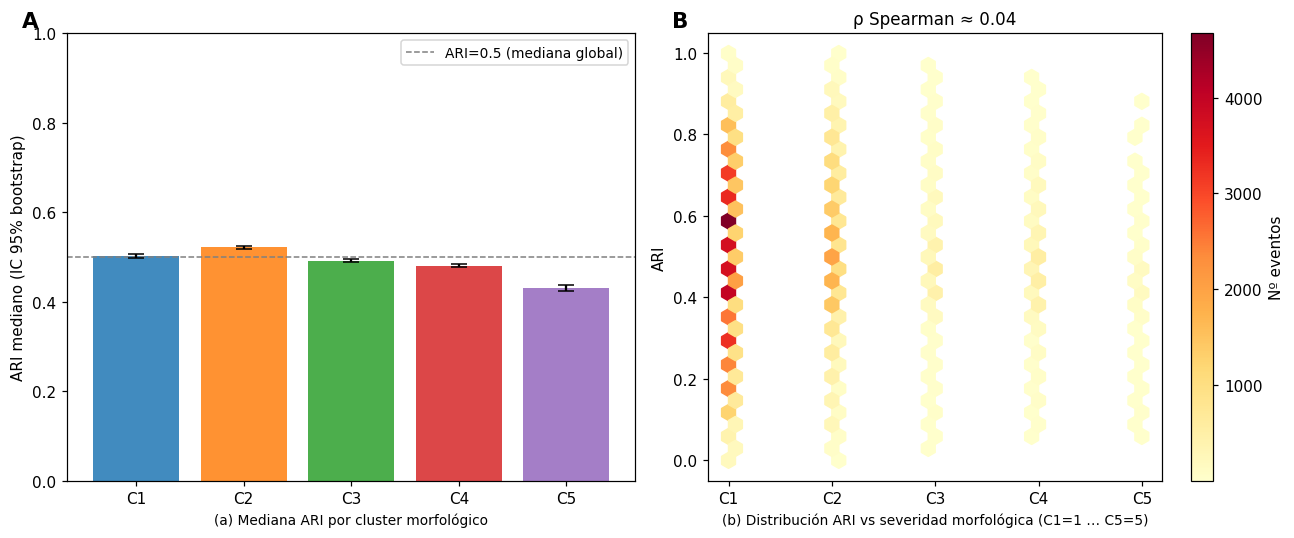

In [6]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: ARI mediano por cluster con IC bootstrap
np.random.seed(42)
medians, ci_lo, ci_hi = [], [], []
for c in cluster_order:
    vals = valid.loc[valid['morphotype_curve']==c, 'ari'].dropna().values
    boot = np.array([np.median(np.random.choice(vals, len(vals), replace=True))
                     for _ in range(1000)])
    medians.append(np.median(vals))
    ci_lo.append(np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5))

x = np.arange(len(cluster_order))
axes[0].bar(x, medians, color=colors, alpha=0.85, zorder=2)
axes[0].errorbar(x, medians,
                 yerr=[np.array(medians)-np.array(ci_lo),
                       np.array(ci_hi)-np.array(medians)],
                 fmt='none', color='black', capsize=5, lw=1.5, zorder=3)
axes[0].axhline(0.5, color='grey', lw=1.0, ls='--', label='ARI=0.5 (mediana global)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cluster_order)
axes[0].set_xlabel('(a) Mediana ARI por cluster morfológico', fontsize=9)
axes[0].set_ylabel('ARI mediano (IC 95% bootstrap)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].text(-0.08, 1.05, 'A', transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', va='top')

# Panel B: hexbin ARI vs severidad morfológica
hb = axes[1].hexbin(valid['sev'], valid['ari'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
fig.colorbar(hb, ax=axes[1], label='Nº eventos')
axes[1].set_xlabel('(b) Distribución ARI vs severidad morfológica (C1=1 … C5=5)', fontsize=9)
axes[1].set_ylabel('ARI', fontsize=10)
axes[1].set_title(f'ρ Spearman ≈ {spearmanr(valid["sev"], valid["ari"])[0]:.2f}',
                  fontsize=11)
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_xticklabels(['C1', 'C2', 'C3', 'C4', 'C5'])
axes[1].text(-0.08, 1.05, 'B', transform=axes[1].transAxes,
             fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig(FIGDIR / '02_ari_ortogonalidad.png', dpi=180, bbox_inches='tight')
plt.show()

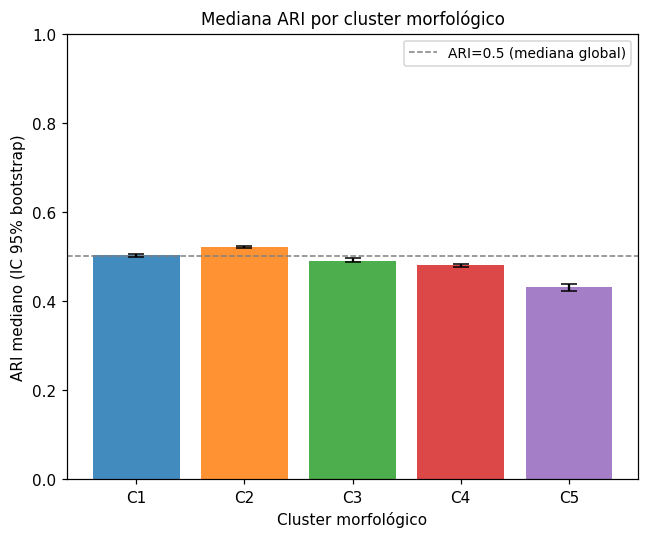

In [12]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

np.random.seed(42)
medians, ci_lo, ci_hi = [], [], []
for c in cluster_order:
    vals = valid.loc[valid['morphotype_curve']==c, 'ari'].dropna().values
    boot = np.array([np.median(np.random.choice(vals, len(vals), replace=True))
                     for _ in range(1000)])
    medians.append(np.median(vals))
    ci_lo.append(np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5))

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(cluster_order))
ax.bar(x, medians, color=colors, alpha=0.85, zorder=2)
ax.errorbar(x, medians,
            yerr=[np.array(medians)-np.array(ci_lo),
                  np.array(ci_hi)-np.array(medians)],
            fmt='none', color='black', capsize=5, lw=1.5, zorder=3)
ax.axhline(0.5, color='grey', lw=1.0, ls='--', label='ARI=0.5 (mediana global)')
ax.set_xticks(x)
ax.set_xticklabels(cluster_order)
ax.set_xlabel('Cluster morfológico', fontsize=10)
ax.set_ylabel('ARI mediano (IC 95% bootstrap)', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Mediana ARI por cluster morfológico', fontsize=11)

plt.tight_layout()
plt.savefig(FIGDIR / '02_ari_mediana_cluster.png', dpi=180, bbox_inches='tight')
plt.show()

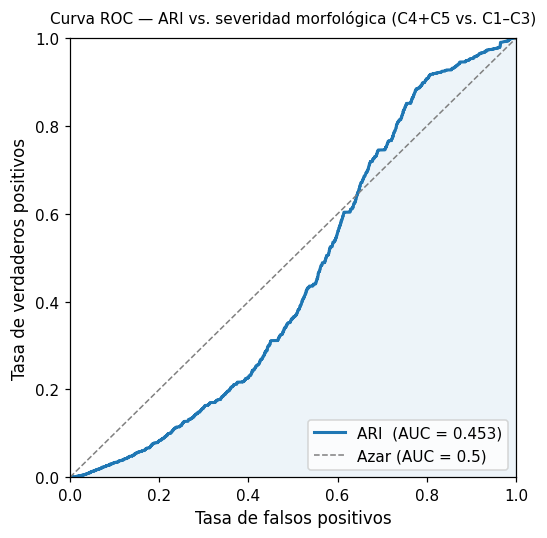

AUC = 0.453


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Curva ROC: ARI discriminando C4+C5 vs C1-C3
y_true = valid['severe'].astype(int)
y_score = valid['ari']
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='#1f77b4', lw=2,
        label=f'ARI  (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Azar (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1f77b4')
ax.set_xlabel('Tasa de falsos positivos', fontsize=11)
ax.set_ylabel('Tasa de verdaderos positivos', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Curva ROC — ARI vs. severidad morfológica (C4+C5 vs. C1–C3)',
             fontsize=10, pad=10)
plt.tight_layout()
plt.savefig(FIGDIR / '02_ari_roc.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'AUC = {auc:.3f}')

## 5. Conclusiones

1. **El ARI es computable** a partir de Gold sin dependencias externas:
   `hr_gain`, `mov_gain` y `drop_pct` están disponibles en
   `events.parquet` para todos los EDOs válidos.

2. **Pesos asimétricos validados (0.6 HR / 0.4 MOV)**: el HR gain
   mediano supera consistentemente al MOV gain en todos los clusters,
   justificando el mayor peso de la señal cardíaca (PPG más confiable
   que el acelerómetro para respuesta simpática).

3. **ARI y morfología son ortogonales** (ρ ≈ 0): capturan dimensiones
   independientes del fenómeno — la geometría del EDO (severidad de la
   desaturación) y la capacidad de respuesta autonómica del organismo.
   Esta ortogonalidad es la base analítica para usar ambas dimensiones
   conjuntamente en el modelo de tesis.

4. **Heterogeneidad intra-cluster**: pacientes con C4–C5 muestran todo
   el espectro del ARI, lo que sugiere que algunos pacientes con EDOs
   morfológicamente severos mantienen respuesta autonómica intacta
   (posible mecanismo protector), mientras otros la pierden.

5. **Próximos pasos** (NB03 en adelante): estratificación del ARI
   por paciente (¿es estable noche a noche?), relación con estados PAC
   multi-escala, y aporte incremental al índice clínico clásico.